<a href="https://colab.research.google.com/github/queenlecode/Event-Database-SQL-Project/blob/main/Data_Analysis_and_Automation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#task 4
import sqlite3

conn = sqlite3.connect('database.db')
conn.execute('PRAGMA foreign_keys = ON')
curs = conn.cursor()

query = """
SELECT
    s.start_time || '-' || s.end_time AS time,
    s.title,
    p.first_name || ' ' || p.last_name AS chair,
    s.room,
    GROUP_CONCAT(sp.first_name || ' ' || sp.last_name || ', ' || sp.affiliation, ' & ') AS speakers
FROM Session s
LEFT JOIN Participant p ON s.chair_id = p.participant_id
LEFT JOIN Session_Speakers ss ON s.session_id = ss.session_id
LEFT JOIN Participant sp ON ss.participant_id = sp.participant_id
GROUP BY s.session_id
ORDER BY s.start_time, s.session_id
"""

curs.execute(query)
sessions = curs.fetchall()

program = []
for row in sessions:
    program.append(row)

program.append(("10:00-10:30", "Coffee break", "", "", ""))
program.append(("11:30-13:00", "Lunch Break", "", "", ""))

program.sort(key=lambda x: x[0])

print("Program:")
print("="*105)
print("{:<15} {:<50} {:<25} {:<10}".format("Time", "Session", "Chair", "Room"))
print("="*105)

for session in program:
    time, title, chair, room, speakers = session

    print("{:<15} {:<50} {:<25} {:<10}".format(time, title, chair, room))

    if speakers:
        print("{:<15} {}".format("", speakers))

    print("-" * 105)

curs.close()
conn.close()


Program:
Time            Session                                            Chair                     Room      
09:00-10:00     AI Ethics and Accountability                       Jan Kudlicka              B2-010    
                Lina Lian, UiB
---------------------------------------------------------------------------------------------------------
09:00-10:00     AI in Healthcare: Opportunities & Risks            Magdalena Ivanovska       B2-020    
                Maria Chen, UiO & Paul Novak, MIT
---------------------------------------------------------------------------------------------------------
10:00-10:30     Coffee break                                                                           
---------------------------------------------------------------------------------------------------------
10:30-11:30     AI, Privacy, and Surveillance in the Digital Age   Wei-Ting Yang             B2-030    
                Omar Haddad, UiO
---------------------------------------

In [ ]:
#task 5
### Conflict management & automated check-in logic
import sqlite3

conn = sqlite3.connect('database.db')
conn.execute('PRAGMA foreign_keys = ON')
curs = conn.cursor()

def register_card(participant_id, current_session_id):
    try:
        #1. checking if participant exists and has role 'regular_participant'
        curs.execute("""
            SELECT participant_id
            FROM Participant
            WHERE participant_id = ?
                AND role = 'regular_participant'
        """, (participant_id,))

        if curs.fetchone() is None:
            print(f'Rejected: Participant {participant_id} is not registered in the system or is not a regular participant.')
            return

        #2. checking if the session exists
        curs.execute("""
            SELECT start_time, end_time, title
            FROM Session
            WHERE session_id = ?
        """, (current_session_id,))

        current_session = curs.fetchone()

        if current_session is None:
            print(f"Rejected: Session {current_session_id} does not exist.")
            return

        start_time, end_time, title = current_session

        #3. checking if the participant is already checked in to this session
        curs.execute("""
            SELECT participant_id, session_id
            FROM Session_Attendance
            WHERE participant_id = ?
              AND session_id = ?
        """, (participant_id, current_session_id))

        if curs.fetchone() is not None:
            print("Rejected: Participant is already checked in to this session.")
            return

        #4. checking if the participant is already checked in to an overlapping session
        curs.execute("""
            SELECT s.title
            FROM Session_Attendance sa
            JOIN Session s ON sa.session_id = s.session_id
            WHERE sa.participant_id = ?
                AND s.start_time < ?
                AND s.end_time > ?
        """, (participant_id, end_time, start_time))

        overlap = curs.fetchone()

        if overlap:
            print(f"Rejected: Participant is already checked in to overlapping session '{overlap[0]}'.")
            return

        #5. record the participant's attendance for the current session
        curs.execute("""
            INSERT INTO Session_Attendance (participant_id, session_id)
            VALUES (?, ?)
        """, (participant_id, current_session_id))

        conn.commit()
        print(f"Accepted: Participant {participant_id} attendance for '{title}' has been registered.")

    except sqlite3.Error as e:
        conn.rollback()
        print(f"Database error: {e}")

# input from user
try:
    participant_id = int(input("Enter participant ID: "))
    current_session_id = int(input("Enter session ID: "))

    register_card(participant_id, current_session_id)

except ValueError:
    print("Invalid input: IDs must be numbers.")

curs.close()
conn.close()


Enter participant ID:  31
Enter session ID:  1


Accepted: Participant 31 attendance for 'AI Ethics and Accountability' has been registered.


In [ ]:
#task 6a
import sqlite3

conn = sqlite3.connect('database.db')
conn.execute('PRAGMA foreign_keys = ON')
curs = conn.cursor()

def submit_rating(session_id, participant_id, rating):
    try:
    #1. check the participant table to see the role
        curs.execute("SELECT role, first_name FROM Participant WHERE participant_id = ?", (participant_id,))
        p_info = curs.fetchone()

        if p_info is None:
            print(f"Rejected: Participant {participant_id} is not registered.")

    #2. check whether they are a regular participant or not
        elif p_info[0] != 'regular_participant':
            print(f"Rejected. Only regular participants can rate sessions.")

        else:
        #3. if they are a valid regular participant, check if they attended and check if they have rated the session
            curs.execute("SELECT rating FROM Session_Attendance WHERE session_id = ? AND participant_id = ?",
                     (session_id, participant_id))
            att_info = curs.fetchone()

            if att_info is None:
                print(f"Rejected: Participant {participant_id} did not attend session {session_id}.")
            elif att_info[0] is not None:
                print(f"Rejected: Participant {participant_id} has already rated this session.")
            else:
                curs.execute("UPDATE Session_Attendance SET rating = ? WHERE session_id = ? AND participant_id = ?",
                         (rating, session_id, participant_id))
                conn.commit()
                print(f"Accepted: Rating {rating} recorded for session {session_id}.")

    except sqlite3.Error as e:
        print(f"Database error: {e}")

# input from user
try:
    session_id = int(input("Enter session ID: "))
    participant_id = int(input("Enter participant ID: "))
    rating = int(input("Enter rating (1-10): "))

    if rating < 1 or rating > 10:
        print("Invalid input: rating must be between 1 and 10.")
    else:
        submit_rating(session_id, participant_id, rating)

except ValueError:
    print("Invalid input: all values must be numbers.")

curs.close()
conn.close()

Enter session ID:  1
Enter participant ID:  31
Enter rating (1-10):  10


Accepted: Rating 10 recorded for session 1.


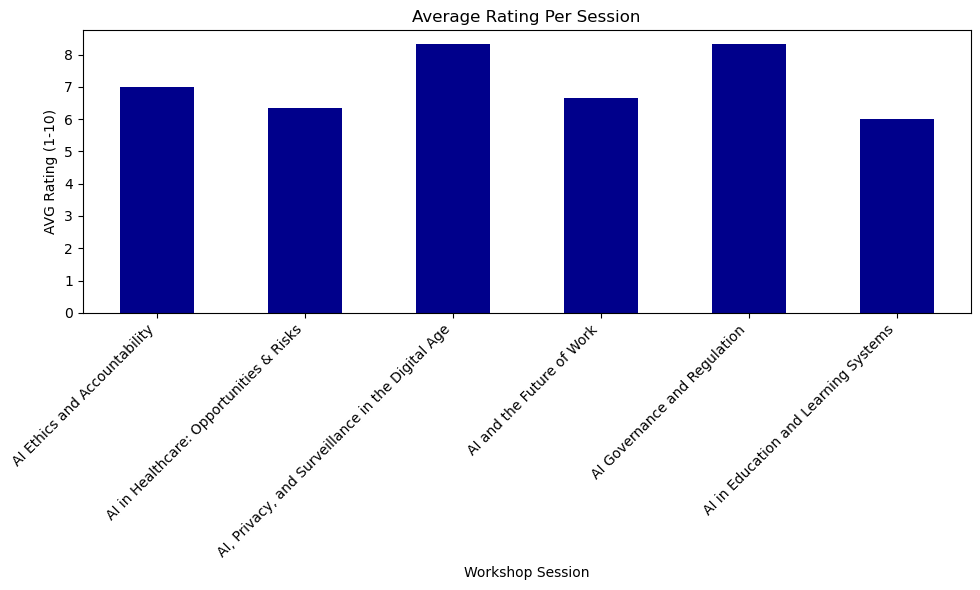

In [ ]:
#task6b
### Data visualization: Session satisfaction analytics
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('database.db')
df = pd.read_sql_query("""
    SELECT s.title as session, AVG(sa.rating) AS avg_rating
    FROM Session_Attendance sa
    JOIN Session s ON sa.session_id = s.session_id
    WHERE sa.rating IS NOT NULL
    GROUP BY s.session_id, s.title
""", conn)
conn.close()

df.plot(
    kind="bar",
    x="session",
    y="avg_rating",
    title="Average Rating Per Session",
    xlabel='Workshop Session',
    ylabel='AVG Rating (1-10)',
    legend=False,
    figsize=(10, 6),
    color='darkblue'
)

plt.xticks(rotation=45, ha='right')  # 45 degree angle, aligned to the right
plt.tight_layout()                   # prevents labels from being cut off
plt.show()